In [33]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras import backend as k
#import activation functions
from tensorflow.keras.layers import Activation


In [34]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
(x_train, y_train), (x_test, y_test) = mnist.load_data() # حطناهم في تابل عشان مينفعش نغير فيهم وده كويس للامان


x_train [shape (60000, 28, 28)] sample patch 
 [[  0  76 246 252 112]
 [  0  85 252 230  25]
 [  0  85 252 223   0]
 [  0  85 252 145   0]
 [  0  86 253 225   0]]


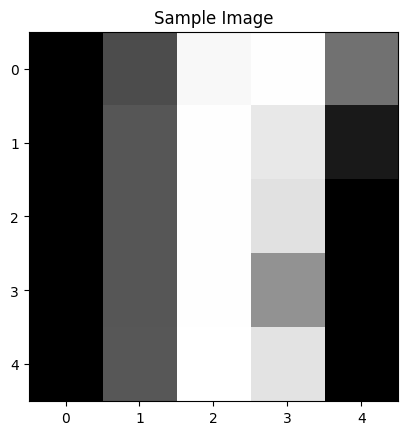

In [35]:
import matplotlib.pyplot as plt
print("x_train [shape %s] sample patch \n" %(str(x_train.shape)),x_train[1,15:20, 5:10])
plt.imshow(x_train[1,15:20, 5:10], cmap='gray')
plt.title('Sample Image')
plt.show()

In [36]:
import tensorflow as tf
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train=x_train.astype('float32')/255 #scaling min-max scaling
x_test=x_test.astype('float32')/255 
#flatten the images (28*28 into 784)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
#one hot encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(200, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(60, activation='relu'),
    tf.keras.layers.Dense(30, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.summary()

c:\Users\el_bostan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 60)             │         6,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,300 (723.83 KB)

 Trainable params: 185,300 (723.83 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

In [38]:
history=model.fit(x_train,y_train, epochs=10, batch_size=64, validation_split=(0.2))

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9068 - loss: 0.3100 - val_accuracy: 0.9557 - val_loss: 0.1443
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9654 - loss: 0.1156 - val_accuracy: 0.9681 - val_loss: 0.1069
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9755 - loss: 0.0787 - val_accuracy: 0.9684 - val_loss: 0.1030
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9815 - loss: 0.0581 - val_accuracy: 0.9684 - val_loss: 0.1092
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9857 - loss: 0.0446 - val_accuracy: 0.9737 - val_loss: 0.0968
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9876 - loss: 0.0365 - val_accuracy: 0.9736 - val_loss: 0.1026
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9897 - loss: 0.0315 - val_accuracy: 0.9724 - val_loss: 0.1051
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9906 - loss: 0.0281 - val_accuracy: 0

In [39]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9780 - loss: 0.0908
Test accuracy: 0.9779999852180481


In [40]:
import numpy as np
def get_random_indices(total_images, num_images):
  indices= np.random.choice(total_images, num_images, replace=False)
  return indices

In [41]:
predictions = model.predict(x_test)
x_test_images = x_test.reshape(-1, 28, 28)
prediction_classes=np.argmax(predictions, axis=1)
true_classes=np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [44]:
num_images_to_show = 5
random_indices = get_random_indices(len(x_test), num_images_to_show)
def plot_images(images,labels,predictions):
    plt.figure(figsize=(10,9))
    for i in range(len(images)):
        plt.subplot(1,len(images),i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"True: {labels[i]}\nPred: {predictions[i]}")
        plt.axis('off')
    plt.show()
        
        

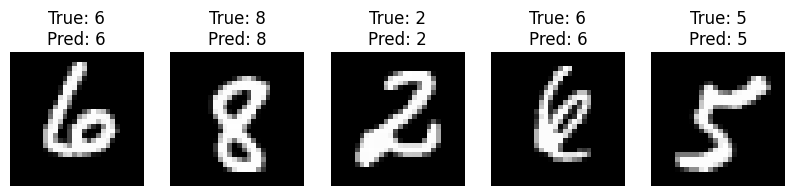

In [45]:
plot_images(x_test_images[random_indices], true_classes[random_indices], prediction_classes[random_indices])